# SMBH only fits

This notebooks carries out the fits where only the SMBH mass is fit. 

In [1]:
import numpy as np
from SMBH_fitter import ModelVelocity, log_prob, MCMC, ReadData

In [2]:
#This deactivates the threading from numpy and is useful to do to make sure the threading from emcee is not affected by the threading from numpy. 
import os
os.environ["OMP_NUM_THREADS"] = "1"

## Initilizations

Here we first read the data file, using the [ReadData](readData.py) object. This is just for conveniency, but it is simply a function that reads and stores the relevant numbers in the file [data.dat](data.dat). 

The second step is to initialize the [ModelVelocity](modelVelocity.py) object, which holds a number of values relevant for the modeling and creates the interpolated values of the F and g functions. See the [README file](README.md) for more details. 

Finally, we set the boundaries for each of the parameters to be used during the MCMC. 

In [3]:
#Read the measurements. 
data = ReadData("data/data.dat")
data_co = ReadData("data/data_co12_to_11_only.dat")
data_central = ReadData("data/data_central_point_only.dat")

In [4]:
#Initialize the modeling object. This takes some time as some functions need to be interpolated. 
modelv = ModelVelocity(data)
modelv_co = ModelVelocity(data_co)
modelv_central = ModelVelocity(data_central)

# All points

In [ ]:
#Set the bounds for each of the parameters we will fit. 

#SMBH Mass
log_Mbh_min  , log_Mbh_max   = 0.0 , 11.0 #Base 10 logarithm of the SMBH mass in units of Solar Masses.

#Host Galaxy Parameters
n_host_min , n_host_max      = 0.50,  2.01 #Sersic index 
Re_host_min, Re_host_max     = 1.1 ,  1.6 #Effective radius in kpc. 
log_Mhost_min, log_Mhost_max = 8.0 , 12.0 #Base 10 logarithm of the total host mass in units of Solar Masses.

#Put the bounds in the right format and order for the MCMC. 
params_min = np.array([n_host_min,  log_Mhost_min, Re_host_min, log_Mbh_min])
params_max = np.array([n_host_max,  log_Mhost_max, Re_host_max, log_Mbh_max])

In [7]:
#Initial guesses. Order is n, log Mbulge, re bulge, log Mbh.
params_init = np.array([4.0, 0., 1.5, 10.])

#Set which parameters are fixed. In this case, it is none, so it is just an array of False values.
ifix  = np.zeros(params_init.shape, dtype=bool)
ifix[0:3] = True

In [9]:
#####
# MCMC
#####

#Set the MCMC object, which is just a convenient wrapper for emcee. 
myMCMC = MCMC(params_init, params_min, params_max, modelv, log_prob, data.sigma_obs, data.sigma_obs_err, ifix=ifix)

#Run th MCMC
myMCMC.runMCMC()

#Save the flatchain. 
myMCMC.save_flat_samples("MCMC_flatchain.no_host.txt")
#myMCMC.load_flat_samples("MCMC_flatchain.no_host.txt")

100%|██████████| 5000/5000 [16:03<00:00,  5.19it/s]


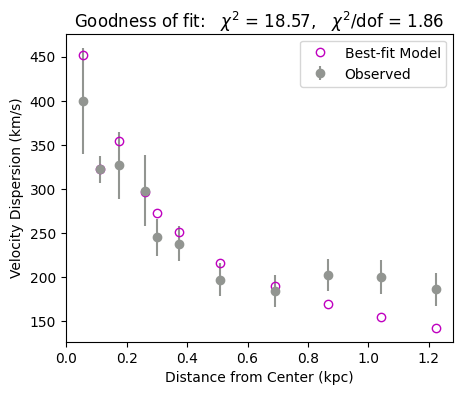

In [10]:
#Plot the best-fit model compared to the data. 
myMCMC.plot_bestfit()

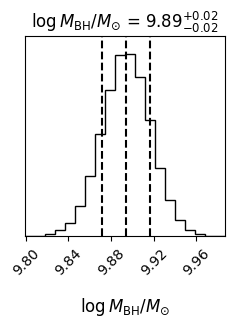

In [11]:
#Make the corner plot.
myMCMC.corner_plot()

# Only CO 4 Data Points

In [12]:
#####
# MCMC
#####

#Set the MCMC object, which is just a convenient wrapper for emcee. 
myMCMC = MCMC(params_init, params_min, params_max, modelv_co, log_prob, data_co.sigma_obs, data_co.sigma_obs_err, ifix=ifix)

#Run th MCMC
myMCMC.runMCMC()

#Save the flatchain. 
myMCMC.save_flat_samples("MCMC_flatchain.no_host.co_only.txt")
#myMCMC.load_flat_samples("MCMC_flatchain.no_host.co_only.txt")

100%|██████████| 5000/5000 [07:18<00:00, 11.41it/s]


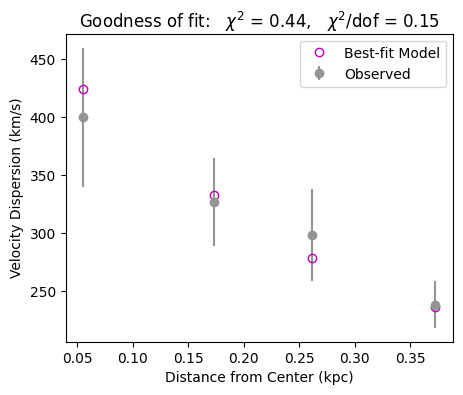

In [13]:
#Plot the best-fit model compared to the data. 
myMCMC.plot_bestfit()

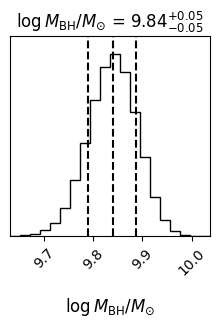

In [14]:
#Make the corner plot.
myMCMC.corner_plot()

# Central data point only

In [8]:
#####
# MCMC
#####

#Set the MCMC object, which is just a convenient wrapper for emcee. 
myMCMC = MCMC(params_init, params_min, params_max, modelv_central, log_prob, data_central.sigma_obs, data_central.sigma_obs_err, ifix=ifix)

#Run th MCMC
myMCMC.runMCMC()

#Save the flatchain. 
myMCMC.save_flat_samples("MCMC_flatchain.no_host.central_only.txt")
#myMCMC.load_flat_samples("MCMC_flatchain.no_host.central_only.txt")

100%|██████████| 5000/5000 [01:53<00:00, 44.04it/s]


/Users/rjassef/Work/Mai_Liao/SMBH_fitter/SMBH_fitter/MCMC.py:140: RuntimeWarning: divide by zero encountered in double_scalars
  chi2_nu = chi2/(len(self.sigma_obs)-(len(params_use)-np.sum(self.ifix)))


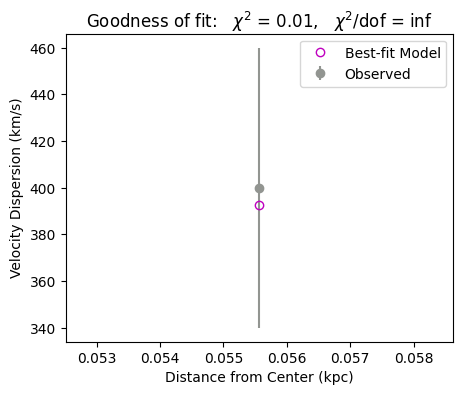

In [9]:
#Plot the best-fit model compared to the data. 
myMCMC.plot_bestfit()

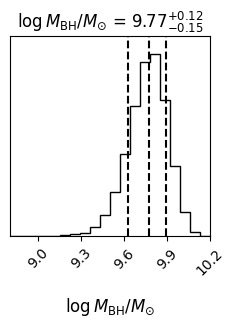

In [10]:
#Make the corner plot.
myMCMC.corner_plot()

# Fixed $M^{\rm Total}_{\rm Host} = 4.5\times 10^{10}~M_{\odot}$

Here the Sersic profile values are fit to those measured from the JWST observations.

In [17]:
#Initial guesses. Order is n, log Mbulge, re bulge, log Mbh.
params_init = np.array([1.64, np.log10(4.5e10), 1.5, 10.])

#Set which parameters are fixed. In this case, it is none, so it is just an array of False values.
ifix  = np.zeros(params_init.shape, dtype=bool)
ifix[0:3] = True

In [18]:
#####
# MCMC
#####

#Set the MCMC object, which is just a convenient wrapper for emcee. 
myMCMC = MCMC(params_init, params_min, params_max, modelv, log_prob, data.sigma_obs, data.sigma_obs_err, ifix=ifix)

#Run th MCMC
myMCMC.runMCMC()

#Save the flatchain. 
myMCMC.save_flat_samples("MCMC_flatchain.fixed_host_4.5e10.txt")
#myMCMC.load_flat_samples("MCMC_flatchain.fixed_host_4.5e10.txt")

100%|██████████| 5000/5000 [14:52<00:00,  5.60it/s]


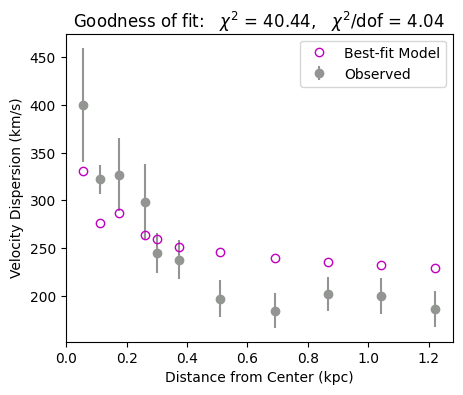

In [19]:
#Plot the best-fit model compared to the data. 
myMCMC.plot_bestfit()

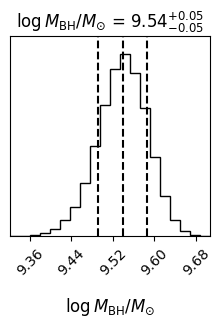

In [20]:
#Make the corner plot.
myMCMC.corner_plot()